First Downlad the dataset from Kaggle

In [1]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("syedanwarafridi/vehicle-sales-data")

# Move to custom directory
target_dir = "./dataset"
os.makedirs(target_dir, exist_ok=True)
shutil.copytree(path, target_dir, dirs_exist_ok=True)

print("Dataset copied to:", target_dir)

c:\Users\youss\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset copied to: ./dataset


Data Downloaded Successfully

Let's exploare the data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
sns.set_theme(style="whitegrid", palette="viridis")

In [4]:
df = pd.read_csv('./dataset/car_prices.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
df.shape

(558837, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


So we have a dataset with 558837 record (row) and 16 feature (column)

In [7]:
df.describe(include='all')

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
count,558837.000000,548536,548438,548186,545642,493485,558833,558837,547017.000000,558743.000000,558088,558088,558837,558799.000000,558825.000000,558825
unique,NaN,96,973,1963,87,4,550297,64,NaN,NaN,46,17,14263,NaN,NaN,3766
top,NaN,Ford,Altima,Base,Sedan,automatic,automatic,fl,NaN,NaN,black,black,nissan-infiniti lt,NaN,NaN,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,NaN,93554,19349,55817,199437,475915,22,82945,NaN,NaN,110970,244329,19693,NaN,NaN,5334
mean,2010.038927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.672365,68320.017767,NaN,NaN,NaN,13769.377495,13611.358810,NaN
std,3.966864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.402832,53398.542821,NaN,NaN,NaN,9679.967174,9749.501628,NaN
min,1982.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,25.000000,1.000000,NaN
25%,2007.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,28371.000000,NaN,NaN,NaN,7100.000000,6900.000000,NaN
50%,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,52254.000000,NaN,NaN,NaN,12250.000000,12100.000000,NaN
75%,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.000000,99109.000000,NaN,NaN,NaN,18300.000000,18200.000000,NaN


In [8]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


# Exploare Dataset 
Dataset Description:


The "Vehicle Sales and Market Trends Dataset" provides a comprehensive collection of information pertaining to the sales transactions of various vehicles. This dataset encompasses details such as the year, make, model, trim, body type, transmission type, VIN (Vehicle Identification Number), state of registration, condition rating, odometer reading, exterior and interior colors, seller information, Manheim Market Report (MMR) values, selling prices, and sale dates.

Key Features:
Vehicle Details: Includes specific information about each vehicle, such as its make, model, trim, and manufacturing year.

Transaction Information: Provides insights into the sales transactions, including selling prices and sale dates.

Market Trends: MMR values offer an estimate of the market value of each vehicle, allowing for analysis of market trends and fluctuations.

Condition and Mileage: Contains data on the condition of the vehicles as well as their odometer readings, enabling analysis of how these factors influence selling prices. 

# Exploare Every cloumn meaning

- 'year': The manufacturing year of the vehicle
- 'make': The brand of manufacturer of the vechile
- 'model': The specific model of the vechile
- 'trim': Additional designation for the vehicle model
- 'body': Trim is the designation that indicates the level of features, equipment, and styling for a particular car model.
- 'tranmission': The type of transmission in the vechile (e.g., automatic)
- 'vin': Vechile Identification Number, a unique code for each vechile.
- 'state': The state where the vechile is registered
- 'condition': Condition of the vehicle, possibly rate on a scale
- 'odometer': The mileage or distance traveled by the vehicle
- 'color': Exterior color of the vehicle
- 'interior': Interior color of the vechile
- 'seller': The entity selling the vechile
- 'mmr': Manheim Market Report, possibly indicating the estimated market value of the vehicle
- 'sellingprice': The price at which the vechile was sold
- 'saledate': The date and time when the vechile was sold


In [9]:
df['state'].unique()

array(['ca', 'tx', 'pa', 'mn', 'az', 'wi', 'tn', 'md', 'fl', 'ne', 'nj',
       'nv', 'oh', 'mi', 'ga', 'va', 'sc', 'nc', 'in', 'il', 'co', 'ut',
       'mo', 'ny', 'ma', 'pr', 'or', 'la', 'wa', 'hi', 'qc', 'ab', 'on',
       'ok', 'ms', 'nm', 'al', '3vwd17aj4fm201708', 'ns',
       '3vwd17aj2fm258506', '3vwd17aj3fm276741', '3vwd17aj2fm285365',
       '3vwd17aj0fm227318', '3vwd17aj6fm218641', '3vwd17aj7fm223475',
       '3vwd17aj5fm297123', '3vwd17aj5fm219943', '3vwd17aj9fm219766',
       '3vwd17aj3fm259017', '3vwd17aj5fm206111', '3vwd17aj5fm273601',
       '3vwd17aj5fm221322', '3vwd17aj5fm268964', '3vwd17aj6fm231972',
       '3vwd17aj7fm222388', '3vwd17aj7fm218440', '3vwd17ajxfm315938',
       '3vwd17aj7fm229552', '3vwd17aj8fm298895', '3vwd17aj4fm236636',
       '3vwd17aj5fm225953', '3vwd17aj7fm326640', '3vwd17aj8fm239622',
       '3vwd17aj2fm261566'], dtype=object)

In [10]:
df['trim'].unique()

array(['LX', '328i SULEV', 'T5', ..., 'pure', 'EWB', 'Power Wagon'],
      shape=(1964,), dtype=object)

In [11]:
len(df['model'].unique())

974

In [12]:
df['make'].unique()

array(['Kia', 'BMW', 'Volvo', 'Nissan', 'Chevrolet', 'Audi', 'Ford',
       'Hyundai', 'Buick', 'Cadillac', 'Acura', 'Lexus', 'Infiniti',
       'Jeep', 'Mercedes-Benz', 'Mitsubishi', 'Mazda', 'MINI',
       'Land Rover', 'Lincoln', 'lincoln', 'Jaguar', 'Volkswagen',
       'Toyota', 'Subaru', 'Scion', 'Porsche', nan, 'bmw', 'Dodge',
       'FIAT', 'Chrysler', 'ford', 'Ferrari', 'Honda', 'GMC',
       'mitsubishi', 'Ram', 'smart', 'chevrolet', 'Bentley', 'chrysler',
       'pontiac', 'Pontiac', 'Saturn', 'Maserati', 'Mercury', 'HUMMER',
       'landrover', 'cadillac', 'land rover', 'mercedes', 'mazda',
       'toyota', 'lexus', 'gmc truck', 'honda', 'nissan', 'porsche',
       'Saab', 'Suzuki', 'dodge', 'subaru', 'Oldsmobile', 'oldsmobile',
       'hyundai', 'jeep', 'Isuzu', 'dodge tk', 'Geo', 'acura',
       'volkswagen', 'suzuki', 'kia', 'audi', 'Rolls-Royce', 'gmc',
       'maserati', 'mazda tk', 'mercury', 'buick', 'hyundai tk',
       'mercedes-b', 'vw', 'Daewoo', 'chev truck', 'f

Lets explore Nons in the dataset

In [13]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

Explore also every unique vlaues in every cloumn

In [14]:
df['make'].unique()

array(['Kia', 'BMW', 'Volvo', 'Nissan', 'Chevrolet', 'Audi', 'Ford',
       'Hyundai', 'Buick', 'Cadillac', 'Acura', 'Lexus', 'Infiniti',
       'Jeep', 'Mercedes-Benz', 'Mitsubishi', 'Mazda', 'MINI',
       'Land Rover', 'Lincoln', 'lincoln', 'Jaguar', 'Volkswagen',
       'Toyota', 'Subaru', 'Scion', 'Porsche', nan, 'bmw', 'Dodge',
       'FIAT', 'Chrysler', 'ford', 'Ferrari', 'Honda', 'GMC',
       'mitsubishi', 'Ram', 'smart', 'chevrolet', 'Bentley', 'chrysler',
       'pontiac', 'Pontiac', 'Saturn', 'Maserati', 'Mercury', 'HUMMER',
       'landrover', 'cadillac', 'land rover', 'mercedes', 'mazda',
       'toyota', 'lexus', 'gmc truck', 'honda', 'nissan', 'porsche',
       'Saab', 'Suzuki', 'dodge', 'subaru', 'Oldsmobile', 'oldsmobile',
       'hyundai', 'jeep', 'Isuzu', 'dodge tk', 'Geo', 'acura',
       'volkswagen', 'suzuki', 'kia', 'audi', 'Rolls-Royce', 'gmc',
       'maserati', 'mazda tk', 'mercury', 'buick', 'hyundai tk',
       'mercedes-b', 'vw', 'Daewoo', 'chev truck', 'f

In [15]:
cat_cols = df.select_dtypes(include=['object']).columns.to_list()

for col in cat_cols:
    print(f"\nnumber of unique values in '{col}':", len(df[col].dropna().astype(str).unique()))


number of unique values in 'make': 96

number of unique values in 'model': 973

number of unique values in 'trim': 1963

number of unique values in 'body': 87

number of unique values in 'transmission': 4

number of unique values in 'vin': 550297

number of unique values in 'state': 64

number of unique values in 'color': 46

number of unique values in 'interior': 17

number of unique values in 'seller': 14263

number of unique values in 'saledate': 3766


There is no duplicates

In [16]:
df.duplicated().sum()

np.int64(0)

# Lets handel missing values

In [17]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [18]:
# Make a copy of the original data
df_prep = df.copy()

In [19]:
# Let's first check whether there is any rows with have all values are nan
df_prep[df_prep.isna().all(axis=1)]

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate


Okay there is no any rows with all values nan 

In [20]:
# first let's inspect the column 'make'

make_col = df_prep[df_prep['make'].isnull()]
make_col.head(10)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
742,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c51cc964387,ca,38.0,23208.0,gray,black,financial services remarketing (lease),47200.0,46000.0,Thu Feb 26 2015 04:30:00 GMT-0800 (PST)
747,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c53cc964410,ca,33.0,19785.0,beige,gray,financial services remarketing (lease),49500.0,46000.0,Thu Feb 12 2015 04:30:00 GMT-0800 (PST)
766,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c54cc964089,ca,37.0,48424.0,black,black,financial services remarketing (lease),42300.0,43000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
798,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c59cc448049,ca,48.0,39825.0,—,gray,financial services remarketing (lease),58100.0,58500.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
803,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c58cc962863,ca,49.0,35093.0,blue,tan,financial services remarketing (lease),45200.0,44500.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
842,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c50cc964249,ca,4.0,33155.0,gray,gray,financial services remarketing (lease),46100.0,45500.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
893,2012,NaN,NaN,NaN,NaN,automatic,wbakc8c50cc435719,ca,24.0,27709.0,—,black,bmw of bakersfield,41800.0,33750.0,Thu Feb 12 2015 04:30:00 GMT-0800 (PST)
1514,2012,NaN,NaN,NaN,NaN,automatic,salmf1e46ca360169,ca,29.0,60828.0,black,black,jpmorgan chase bank n.a.,47600.0,40500.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
1539,2012,NaN,NaN,NaN,NaN,automatic,salmf1e48ca360609,ca,29.0,62786.0,black,black,jpmorgan chase bank n.a.,46400.0,42500.0,Thu Feb 12 2015 04:30:00 GMT-0800 (PST)
2082,2011,NaN,NaN,NaN,NaN,automatic,1ftlr1fe5bpa06821,ca,NaN,1.0,white,—,onemain rem/e motorcars,18300.0,11500.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)


We noticed that the make, model, trim, and body is almost nan in most nan features

In [21]:
# we need to check wheter there is a relation between these four features in missing values

feat_nans = df_prep[df_prep[['make','model','trim','body']].isna().all(axis=1)]
feat_nans

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
742,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c51cc964387,ca,38.0,23208.0,gray,black,financial services remarketing (lease),47200.0,46000.0,Thu Feb 26 2015 04:30:00 GMT-0800 (PST)
747,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c53cc964410,ca,33.0,19785.0,beige,gray,financial services remarketing (lease),49500.0,46000.0,Thu Feb 12 2015 04:30:00 GMT-0800 (PST)
766,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c54cc964089,ca,37.0,48424.0,black,black,financial services remarketing (lease),42300.0,43000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
798,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c59cc448049,ca,48.0,39825.0,—,gray,financial services remarketing (lease),58100.0,58500.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
803,2012,NaN,NaN,NaN,NaN,automatic,wbakb8c58cc962863,ca,49.0,35093.0,blue,tan,financial services remarketing (lease),45200.0,44500.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558545,2000,NaN,NaN,NaN,NaN,automatic,4n2xn11txyd844711,ma,31.0,108900.0,green,gray,boch toyota/scion south,1275.0,1100.0,Thu Jun 18 2015 11:30:00 GMT-0700 (PDT)
558617,2007,NaN,NaN,NaN,NaN,automatic,jtjbt20x770129305,pa,41.0,66393.0,—,beige,r hollenshead auto sales inc,18150.0,18500.0,Fri Jun 19 2015 02:00:00 GMT-0700 (PDT)
558736,2011,NaN,NaN,NaN,NaN,automatic,4a4jn2as6be029938,nv,41.0,67820.0,silver,black,imperial rides,9175.0,10500.0,Fri Jun 19 2015 05:00:00 GMT-0700 (PDT)
558773,2005,NaN,NaN,NaN,NaN,automatic,1g1yy24u355116011,tx,24.0,114787.0,burgundy,black,hopper motorplex inc,15400.0,14800.0,Wed Jun 24 2015 03:15:00 GMT-0700 (PDT)


Done we found a good relation that when the 'make' column is nan the rest of the three colums are nan also because number of nan in the 'make' column is 10301 and that's the same number when these four features are combined when they nan  

Let's delete them

In [22]:
df_prep = df_prep[~df_prep[['make','model','trim','body']].isna().all(axis=1)]

In [23]:
# check the missing values
df_prep.isna().sum()

year                0
make                0
model              98
trim              350
body             2894
transmission    63591
vin                 4
state               0
condition       11733
odometer           90
color             734
interior          734
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [24]:
# let's check rest coulmn

feat_nans = df_prep[df_prep[['make','model','trim','body']].isna().any(axis=1)]
feat_nans.head(20)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
72,2014,BMW,NaN,750Li,Sedan,automatic,wbaye8c59ed134514,ca,43.0,12172.0,black,black,financial services remarketing (lease),67000.0,66000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
468,2013,lincoln,mkt,awd v6,NaN,automatic,2lmhj5nk1dbl52290,ca,41.0,74874.0,black,black,remarketing by ge/manheim southern california,19300.0,17750.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)
743,2012,bmw,750i,xdr 750i xdriv,NaN,automatic,wbakc6c5xcc395623,ca,4.0,50790.0,gray,black,financial services remarketing (lease),33900.0,33500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
770,2012,bmw,750li,750li,NaN,automatic,wbakb8c50cc963182,ca,37.0,31762.0,black,black,financial services remarketing (lease),45000.0,45000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
793,2012,bmw,750i,750i,NaN,automatic,wbaka8c54ccy37992,ca,49.0,53016.0,white,gray,financial services remarketing (lease),31300.0,34250.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
794,2012,bmw,750li,750li,NaN,automatic,wbakb8c56cc963431,ca,34.0,24739.0,white,gray,financial services remarketing (lease),47000.0,46750.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
799,2012,bmw,750i,750i,NaN,automatic,wbaka8c59cds99963,ca,39.0,36156.0,blue,gray,financial services remarketing (lease),34800.0,35500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
814,2012,bmw,750li,750li,NaN,automatic,wbakb8c56cc964045,ca,49.0,17647.0,gray,black,financial services remarketing (lease),49000.0,49000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
819,2012,bmw,750i,750i,NaN,automatic,wbaka8c51ccy37982,ca,4.0,40183.0,gray,blue,financial services remarketing (lease),34000.0,35500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
836,2012,bmw,750i,750i,NaN,automatic,wbaka8c59ccy37616,ca,35.0,42482.0,black,black,financial services remarketing (lease),33500.0,33000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


We found an important thing we have many values but with the same name but in different format like bmw, BMW. We must deal with this 

In [25]:
df_prep['make'] = df_prep['make'].str.lower()

In [26]:
df_prep['make'].unique()

array(['kia', 'bmw', 'volvo', 'nissan', 'chevrolet', 'audi', 'ford',
       'hyundai', 'buick', 'cadillac', 'acura', 'lexus', 'infiniti',
       'jeep', 'mercedes-benz', 'mitsubishi', 'mazda', 'mini',
       'land rover', 'lincoln', 'jaguar', 'volkswagen', 'toyota',
       'subaru', 'scion', 'porsche', 'dodge', 'fiat', 'chrysler',
       'ferrari', 'honda', 'gmc', 'ram', 'smart', 'bentley', 'pontiac',
       'saturn', 'maserati', 'mercury', 'hummer', 'landrover', 'mercedes',
       'gmc truck', 'saab', 'suzuki', 'oldsmobile', 'isuzu', 'dodge tk',
       'geo', 'rolls-royce', 'mazda tk', 'hyundai tk', 'mercedes-b', 'vw',
       'daewoo', 'chev truck', 'ford tk', 'plymouth', 'ford truck',
       'tesla', 'airstream', 'dot', 'aston martin', 'fisker',
       'lamborghini', 'lotus'], dtype=object)

In [27]:
brand_map = {
    "mercedes": "mercedes-benz",
    "mercedes-b": "mercedes-benz",
    "landrover": "land rover",
    "vw": "volkswagen",
    "gmc truck": "gmc",
    "chev truck": "chevrolet",
    "ford tk": "ford",
    "ford truck": "ford",
    "dodge tk": "dodge",
    "hyundai tk": "hyundai",
    "mazda tk": "mazda"
}

In [28]:
df_prep["make"] = df_prep["make"].replace(brand_map)

In [29]:
df_prep['make'].unique()

array(['kia', 'bmw', 'volvo', 'nissan', 'chevrolet', 'audi', 'ford',
       'hyundai', 'buick', 'cadillac', 'acura', 'lexus', 'infiniti',
       'jeep', 'mercedes-benz', 'mitsubishi', 'mazda', 'mini',
       'land rover', 'lincoln', 'jaguar', 'volkswagen', 'toyota',
       'subaru', 'scion', 'porsche', 'dodge', 'fiat', 'chrysler',
       'ferrari', 'honda', 'gmc', 'ram', 'smart', 'bentley', 'pontiac',
       'saturn', 'maserati', 'mercury', 'hummer', 'saab', 'suzuki',
       'oldsmobile', 'isuzu', 'geo', 'rolls-royce', 'daewoo', 'plymouth',
       'tesla', 'airstream', 'dot', 'aston martin', 'fisker',
       'lamborghini', 'lotus'], dtype=object)

Also the body has several mistakes un writing let's fix it

In [30]:
df_prep['body'].value_counts()

body
Sedan          199437
SUV            119292
sedan           41906
suv             24552
Hatchback       21380
                ...  
CTS-V Wagon         1
Ram Van             1
g37 coupe           1
cab plus 4          1
cts wagon           1
Name: count, Length: 87, dtype: int64

In [31]:
df_prep['body'] = df_prep['body'].str.lower()

In [32]:
df_prep['body'].value_counts()

body
sedan                      241343
suv                        143844
hatchback                   26237
minivan                     25529
coupe                       17752
crew cab                    16394
wagon                       16129
convertible                 10476
supercrew                    9033
g sedan                      7417
supercab                     5311
regular cab                  4850
van                          4528
extended cab                 4507
quad cab                     4095
e-series van                 1823
double cab                   1601
g coupe                      1593
crewmax cab                   565
king cab                      532
g convertible                 323
genesis coupe                 294
access cab                    294
koup                          180
club cab                      178
cts coupe                     158
mega cab                      111
elantra coupe                 103
beetle convertible             59
promaster

As we can see there is many duplicates in this values:

Final Body Categories will be:
- sedan
- suv
- hatchback
- minivan
- coupe
- convertible
- wagon
- pickup  (all truck cab configurations)
- van

This reduces noise, prevents overfitting, and improves model stability.

In [33]:
body_map = {
    # Sedans
    "sedan": "sedan",
    "g sedan": "sedan",

    # SUVs
    "suv": "suv",

    # Hatchback
    "hatchback": "hatchback",

    # Minivan
    "minivan": "minivan",

    # Coupes
    "coupe": "coupe",
    "g coupe": "coupe",
    "genesis coupe": "coupe",
    "elantra coupe": "coupe",
    "koup": "coupe",
    "cts coupe": "coupe",
    "q60 coupe": "coupe",
    "cts-v coupe": "coupe",
    "g37 coupe": "coupe",

    # Convertibles
    "convertible": "convertible",
    "g convertible": "convertible",
    "beetle convertible": "convertible",
    "q60 convertible": "convertible",
    "granturismo convertible": "convertible",
    "g37 convertible": "convertible",

    # Wagons
    "wagon": "wagon",
    "tsx sport wagon": "wagon",
    "cts wagon": "wagon",
    "cts-v wagon": "wagon",

    # Vans
    "van": "van",
    "e-series van": "van",
    "transit van": "van",
    "promaster cargo van": "van",
    "ram van": "van",

    # Pickup trucks (all cab variants)
    "crew cab": "pickup",
    "supercrew": "pickup",
    "supercab": "pickup",
    "regular cab": "pickup",
    "regular-cab": "pickup",
    "extended cab": "pickup",
    "quad cab": "pickup",
    "double cab": "pickup",
    "crewmax cab": "pickup",
    "king cab": "pickup",
    "mega cab": "pickup",
    "club cab": "pickup",
    "cab plus": "pickup",
    "cab plus 4": "pickup",
    "xtracab": "pickup",
    "access cab": "pickup",
}

In [34]:
df_prep["body"] = df_prep["body"].replace(body_map)

In [35]:
df_prep['body'].value_counts()

body
sedan          248760
suv            143844
pickup          47540
hatchback       26237
minivan         25529
coupe           20163
wagon           16180
convertible     10933
van              6430
navitgation        26
Name: count, dtype: int64

Okay we handle it so return to our matter 

In [36]:
df_prep.isna().sum()

year                0
make                0
model              98
trim              350
body             2894
transmission    63591
vin                 4
state               0
condition       11733
odometer           90
color             734
interior          734
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [37]:
# let's check rest coulmn

feat_nans = df_prep[df_prep[['make','model','trim','body']].isna().any(axis=1)]
feat_nans.head(20)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
72,2014,bmw,NaN,750Li,sedan,automatic,wbaye8c59ed134514,ca,43.0,12172.0,black,black,financial services remarketing (lease),67000.0,66000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
468,2013,lincoln,mkt,awd v6,NaN,automatic,2lmhj5nk1dbl52290,ca,41.0,74874.0,black,black,remarketing by ge/manheim southern california,19300.0,17750.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)
743,2012,bmw,750i,xdr 750i xdriv,NaN,automatic,wbakc6c5xcc395623,ca,4.0,50790.0,gray,black,financial services remarketing (lease),33900.0,33500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
770,2012,bmw,750li,750li,NaN,automatic,wbakb8c50cc963182,ca,37.0,31762.0,black,black,financial services remarketing (lease),45000.0,45000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
793,2012,bmw,750i,750i,NaN,automatic,wbaka8c54ccy37992,ca,49.0,53016.0,white,gray,financial services remarketing (lease),31300.0,34250.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
794,2012,bmw,750li,750li,NaN,automatic,wbakb8c56cc963431,ca,34.0,24739.0,white,gray,financial services remarketing (lease),47000.0,46750.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
799,2012,bmw,750i,750i,NaN,automatic,wbaka8c59cds99963,ca,39.0,36156.0,blue,gray,financial services remarketing (lease),34800.0,35500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
814,2012,bmw,750li,750li,NaN,automatic,wbakb8c56cc964045,ca,49.0,17647.0,gray,black,financial services remarketing (lease),49000.0,49000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
819,2012,bmw,750i,750i,NaN,automatic,wbaka8c51ccy37982,ca,4.0,40183.0,gray,blue,financial services remarketing (lease),34000.0,35500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
836,2012,bmw,750i,750i,NaN,automatic,wbaka8c59ccy37616,ca,35.0,42482.0,black,black,financial services remarketing (lease),33500.0,33000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


We found that the bmw almost has no body column we can inspect more

In [38]:
condition = (df_prep["make"] == "bmw") & (df_prep["model"].isin(["750li", "750i"]))

total_bmw = df_prep[condition].shape[0]
missing_bmw_body = df_prep[condition & df_prep["body"].isna()].shape[0]

print("Total BMW rows:", total_bmw)
print("Missing BMW body rows:", missing_bmw_body)


Total BMW rows: 60
Missing BMW body rows: 60


we found that the bmw when its model is '750li' and '750i' has no body feature so I will impute it with 'unkwon'

In [39]:
df_prep.loc[condition, "body"] = df_prep.loc[condition, "body"].fillna("unknown")

In [40]:
df_prep.isna().sum()

year                0
make                0
model              98
trim              350
body             2834
transmission    63591
vin                 4
state               0
condition       11733
odometer           90
color             734
interior          734
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [41]:
# let's check model coulmn

feat_nans = df_prep[df_prep[['model']].isna().all(axis=1)]
feat_nans.head(20)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
72,2014,bmw,NaN,750Li,sedan,automatic,wbaye8c59ed134514,ca,43.0,12172.0,black,black,financial services remarketing (lease),67000.0,66000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
31262,2014,bmw,NaN,750i,sedan,automatic,wbaya8c52ed825069,ga,44.0,4488.0,silver,black,global imports,67000.0,64200.0,Thu Dec 18 2014 10:00:00 GMT-0800 (PST)
61951,2014,bmw,NaN,750Li xDrive,sedan,automatic,wbayf8c57ed653381,oh,48.0,387.0,black,black,bmw na manheim new jersey,72000.0,72500.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)
61955,2014,bmw,NaN,750Li xDrive,sedan,automatic,wbayf8c51ed142328,oh,46.0,414.0,white,—,bmw na manheim new jersey,72000.0,68500.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)
61956,2014,bmw,NaN,750i,sedan,automatic,wbaya8c55ed228269,oh,48.0,4796.0,NaN,NaN,bmw north america raa,66000.0,75000.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)
61972,2014,bmw,NaN,750Li xDrive,sedan,automatic,wbayf8c57ed653316,oh,48.0,361.0,black,black,bmw na manheim new jersey,72000.0,78500.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)
61978,2014,bmw,NaN,750Li xDrive,sedan,automatic,wbayf8c59ed653334,oh,5.0,243.0,black,black,bmw na manheim new jersey,72000.0,73500.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)
61986,2014,bmw,NaN,750Li xDrive,sedan,automatic,wbayf8c54ed653404,oh,49.0,795.0,black,black,bmw na manheim new jersey,72000.0,72500.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)
61990,2014,bmw,NaN,750Li xDrive,sedan,automatic,wbayf8c50ed142515,oh,46.0,1511.0,white,—,bmw na manheim new jersey,72000.0,76500.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)
61992,2014,bmw,NaN,750Li xDrive,sedan,automatic,wbayf8c5xed653388,oh,49.0,290.0,black,black,bmw na manheim new jersey,72000.0,72000.0,Tue Dec 30 2014 14:00:00 GMT-0800 (PST)


In [42]:
# check the make unique values
feat_nans['make'].unique()

array(['bmw', 'audi'], dtype=object)

In [43]:
feat_nans['make'].value_counts()

make
bmw     86
audi    12
Name: count, dtype: int64

In [44]:
# okay we know find that the bmw and audi has many values missing in model column 
# Let's check them when they have values

bmw_audi = df_prep[df_prep["make"].isin(["bmw", "audi"])]
bmw_audi.head(20)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
2,2014,bmw,3 Series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
4,2014,bmw,6 Series Gran Coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
6,2014,bmw,M5,Base,sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
8,2014,audi,A4,2.0T Premium Plus quattro,sedan,automatic,wauffafl3en030343,ca,42.0,9557.0,white,black,audi mission viejo,32100.0,32250.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)
10,2014,audi,A6,3.0T Prestige quattro,sedan,automatic,wauhgafc0en062916,ca,48.0,14414.0,black,black,desert auto trade,47300.0,49750.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
17,2014,audi,Q5,2.0T Premium Plus quattro,suv,automatic,wa1lfafpxea085074,ca,49.0,7983.0,white,black,audi north scottsdale,37100.0,40000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
19,2014,bmw,6 Series,650i,convertible,automatic,wbayp9c53ed169260,ca,34.0,8819.0,black,black,the hertz corporation,68000.0,67200.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
21,2014,bmw,5 Series,528i,sedan,automatic,wba5a5c51ed501631,ca,29.0,25969.0,black,black,financial services remarketing (lease),34200.0,30000.0,Tue Feb 03 2015 04:30:00 GMT-0800 (PST)
23,2015,audi,A3,1.8 TFSI Premium,sedan,automatic,wauacgff7f1002327,ca,49.0,5826.0,gray,black,audi north scottsdale,24000.0,23750.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
24,2014,bmw,6 Series,650i,convertible,automatic,wbayp9c57ed169262,ca,38.0,10736.0,black,black,the hertz corporation,67000.0,65000.0,Tue Jan 06 2015 12:30:00 GMT-0800 (PST)


We can Impute it with knn

Important Note:

Some columns still showed the value "nan" after KNN imputation because "nan" was not a real missing value. When I converted the columns to string earlier, true NaN values (np.nan) were converted into the literal string "nan". KNNImputer can only impute numeric NaN values, not string values. Therefore, "nan" remained unchanged. I fixed this by replacing "nan" strings with actual np.nan before encoding and re-running KNN imputation.

So I update the code to handle this situation

In [47]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import KNNImputer

for col in ["make", "model", "trim", "body"]:
    df_prep[col] = df_prep[col].replace("nan", np.nan)
    df_prep[col] = df_prep[col].replace("", np.nan)

le_make  = LabelEncoder()
le_model = LabelEncoder()
le_trim  = LabelEncoder()
le_body  = LabelEncoder()
 
encoders = {
    "make":  le_make,
    "model": le_model,
    "trim":  le_trim,
    "body":  le_body,
}
 
for col, le in encoders.items():
    non_null_vals = df_prep[col].dropna()
    le.fit(non_null_vals)
 
    df_prep[col + "_encoded"] = df_prep[col].map(
        lambda x, _le=le: _le.transform([x])[0] if pd.notna(x) else np.nan
    )
 


features = [
    "make_encoded",
    "model_encoded",
    "trim_encoded",
    "body_encoded",
    "year",
]
 
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_prep[features])
 
imputer = KNNImputer(n_neighbors=5, weights="distance")
imputed_scaled = imputer.fit_transform(scaled_data)
 
df_prep[features] = scaler.inverse_transform(imputed_scaled)
 
 

for col, le in encoders.items():
    encoded_col = col + "_encoded"
    max_idx = len(le.classes_) - 1
 
    
    df_prep[encoded_col] = (
        df_prep[encoded_col]
        .round()
        .astype(int)
        .clip(0, max_idx)
    )
 
    df_prep[col] = le.inverse_transform(df_prep[encoded_col])


Checking for null vales and 'non' values 

In [48]:
print("\nNull counts AFTER imputation")
print(df_prep[["make", "model", "trim", "body"]].isna().sum())
 
print("\n'nan' string counts AFTER imputation")
for col in ["make", "model", "trim", "body"]:
    nan_strings = (df_prep[col] == "nan").sum()
    print(f"  {col}: {nan_strings} 'nan' strings")
 
print("\nSample of imputed rows")
print(df_prep[["make", "model", "trim", "body"]].head(10))


Null counts AFTER imputation
make     0
model    0
trim     0
body     0
dtype: int64

'nan' string counts AFTER imputation
  make: 0 'nan' strings
  model: 0 'nan' strings
  trim: 0 'nan' strings
  body: 0 'nan' strings

Sample of imputed rows
        make                model                       trim         body
0        kia              Sorento                         LX          suv
1        kia              Sorento                         LX          suv
2        bmw             3 Series                 328i SULEV        sedan
3      volvo                  S60                         T5        sedan
4        bmw  6 Series Gran Coupe                       650i        sedan
5     nissan               Altima                      2.5 S        sedan
6        bmw                   M5                       Base        sedan
7  chevrolet                Cruze                        1LT        sedan
8       audi                   A4  2.0T Premium Plus quattro        sedan
9  chevrolet  

We did it successfully

In [49]:
df_prep.isna().sum()

year                 0
make                 0
model                0
trim                 0
body                 0
transmission     63591
vin                  4
state                0
condition        11733
odometer            90
color              734
interior           734
seller               0
mmr                 38
sellingprice        12
saledate            12
make_encoded         0
model_encoded        0
trim_encoded         0
body_encoded         0
dtype: int64

In [50]:
# now Let's check the rest of coulmns with missing values

df_prep['transmission'].unique()

array(['automatic', nan, 'manual', 'Sedan', 'sedan'], dtype=object)

In [51]:
# let's make fix 'Sedan' and sedan
df_prep['transmission'] = df_prep['transmission'].str.lower()

In [52]:
df_prep['transmission'].unique()

array(['automatic', nan, 'manual', 'sedan'], dtype=object)

In [53]:
df_prep['transmission'].value_counts()

transmission
automatic    467926
manual        16993
sedan            26
Name: count, dtype: int64

sedan is not a transmission so we need to fix it first

In [54]:
df_prep.loc[df_prep["transmission"] == "sedan", "transmission"] = np.nan

In [55]:
df_prep['transmission'].value_counts()

transmission
automatic    467926
manual        16993
Name: count, dtype: int64

All is ready to handle this feature now 

I will use `Stratified imputation by make/model`
This is usually the best real‑world option:
For each car model:

- If all Toyota Camry cars are automatic → fill automatic
- If Subaru WRX is usually manual → fill manual

In [56]:
df_prep["transmission"] = (
    df_prep.groupby(["make", "model"])["transmission"]
           .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "automatic"))
)

In [57]:
df_prep['transmission'].isna().sum()

np.int64(0)

In [58]:
df_prep['transmission'].value_counts()

transmission
automatic    531430
manual        17106
Name: count, dtype: int64

So the transmission is Done

In [59]:
df_prep.isna().sum()

year                 0
make                 0
model                0
trim                 0
body                 0
transmission         0
vin                  4
state                0
condition        11733
odometer            90
color              734
interior           734
seller               0
mmr                 38
sellingprice        12
saledate            12
make_encoded         0
model_encoded        0
trim_encoded         0
body_encoded         0
dtype: int64

In [60]:
df_prep.head(10)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,make_encoded,model_encoded,trim_encoded,body_encoded
0,2015.0,kia,Sorento,LX,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),26,658,998,7
1,2015.0,kia,Sorento,LX,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),26,658,998,7
2,2014.0,bmw,3 Series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST),5,9,283,6
3,2015.0,volvo,S60,T5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),54,596,1399,6
4,2014.0,bmw,6 Series Gran Coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),5,42,498,6
5,2015.0,nissan,Altima,2.5 S,sedan,automatic,1n4al3ap1fn326013,ca,1.0,5554.0,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.0,10900.0,Tue Dec 30 2014 12:00:00 GMT-0800 (PST),38,76,120,6
6,2014.0,bmw,M5,Base,sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST),5,426,560,6
7,2014.0,chevrolet,Cruze,1LT,sedan,automatic,1g1pc5sb2e7128460,ca,2.0,28617.0,black,black,enterprise vehicle exchange / tra / rental / t...,11900.0,9800.0,Tue Dec 16 2014 13:00:00 GMT-0800 (PST),8,201,62,6
8,2014.0,audi,A4,2.0T Premium Plus quattro,sedan,automatic,wauffafl3en030343,ca,42.0,9557.0,white,black,audi mission viejo,32100.0,32250.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),3,59,84,6
9,2014.0,chevrolet,Camaro,LT,convertible,automatic,2g1fb3d37e9218789,ca,3.0,4809.0,red,black,d/m auto sales inc,26300.0,17500.0,Tue Jan 20 2015 04:00:00 GMT-0800 (PST),8,150,981,0


In 'odometer' we can impute with median it's a small value will not affect

In [61]:
df_prep["odometer"] = df_prep["odometer"].fillna(df_prep["odometer"].median())

In [62]:
df_prep.isna().sum()

year                 0
make                 0
model                0
trim                 0
body                 0
transmission         0
vin                  4
state                0
condition        11733
odometer             0
color              734
interior           734
seller               0
mmr                 38
sellingprice        12
saledate            12
make_encoded         0
model_encoded        0
trim_encoded         0
body_encoded         0
dtype: int64

There also one issue that the max was 999,999 (clearly junk). Cap at 300,000 miles (reasonable used-car max)

In [63]:
# max was 999,999 (clearly junk). Cap at 300,000 miles (reasonable used-car max)
# Also drop suspiciously low values (odometer = 0 or 1 is almost always a data error)

before = len(df_prep)
df_prep = df_prep[(df_prep['odometer'] >= 10) & (df_prep['odometer'] <= 300_000)]
print(f"Odometer filter: dropped {before - len(df_prep)} rows")

Odometer filter: dropped 2044 rows


Now we need to impute the condition column

I imputed missing values in the condition column using the median condition for each (make, model), with a fallback to the overall dataset median. This method is ideal because:

Condition is a numeric, ordinal variable, so the median is the most reliable statistic (it is robust to outliers and preserves the scale).
Cars of the same make and model usually have similar condition levels, so imputing within each group gives more realistic values than a global fill.
If a specific model has all its condition values missing, the global median ensures no gaps remain.
This approach keeps the distribution natural, avoids bias, and is computationally simple and stable for large datasets.

In [64]:
# group-wise imputation
global_med = df_prep["condition"].median()

df_prep["condition"] = (
    df_prep.groupby(["make", "model"])["condition"]
           .transform(lambda x: x.fillna(x.median() if not x.dropna().empty else global_med))
)


In [65]:
df_prep.isna().sum()

year               0
make               0
model              0
trim               0
body               0
transmission       0
vin                2
state              0
condition          0
odometer           0
color            714
interior         714
seller             0
mmr               28
sellingprice      12
saledate          12
make_encoded       0
model_encoded      0
trim_encoded       0
body_encoded       0
dtype: int64

We almost done 98% of handel missing values we just now need to impute sellingprice

I imputed missing values in sellingprice using the median price of cars with the same make, model, and year. This method is ideal because similar cars usually have similar selling prices, and the median is robust to outliers. Since only 12 values were missing, group‑based median imputation provides realistic and accurate estimates without introducing noise or bias into the dataset.

In [66]:
global_price_med = df_prep["sellingprice"].median()

df_prep["sellingprice"] = (
    df_prep.groupby(["make", "model", "year"])["sellingprice"]
           .transform(lambda x: x.fillna(
               x.median() if not x.dropna().empty else global_price_med
           ))
)


In [67]:
df_prep.isna().sum()

year               0
make               0
model              0
trim               0
body               0
transmission       0
vin                2
state              0
condition          0
odometer           0
color            714
interior         714
seller             0
mmr               28
sellingprice       0
saledate          12
make_encoded       0
model_encoded      0
trim_encoded       0
body_encoded       0
dtype: int64

Another issue in selling price is min was $1 (impossible), max was $230,000 (possibly legitimate for luxury/exotic).

In [68]:
before = len(df_prep)
df_prep = df_prep[(df_prep['sellingprice'] >= 500) & (df_prep['sellingprice'] <= 150_000)]
print(f"Selling price filter: dropped {before - len(df_prep)} rows")

Selling price filter: dropped 4532 rows


#### Feature Engineering


I thinked to add another column which is vechile age to represent the age of the vechile by 

subtracting the year was made at and the year when sold

In [70]:
df_prep['saledate'] = pd.to_datetime(df_prep['saledate'], utc=True, errors='coerce')

df_prep['sale_year']       = df_prep['saledate'].dt.year
df_prep['sale_month']      = df_prep['saledate'].dt.month
df_prep['sale_dayofweek']  = df_prep['saledate'].dt.day_name()

print("saledate parsed. Null count:", df_prep['saledate'].isna().sum())
print(df_prep[['saledate','sale_year','sale_month','sale_dayofweek']].head(3))

saledate parsed. Null count: 28
                   saledate  sale_year  sale_month sale_dayofweek
0 2014-12-16 04:30:00+00:00     2014.0        12.0        Tuesday
1 2014-12-16 04:30:00+00:00     2014.0        12.0        Tuesday
2 2015-01-14 20:30:00+00:00     2015.0         1.0      Wednesday


In [71]:
# Drop the null values in dates
df_prep.dropna(subset=['saledate', 'sale_year', 'sale_month', 'sale_dayofweek'], inplace=True)
print("Rows after dropping null saledates:", len(df_prep))

Rows after dropping null saledates: 541932


Feature Engineering part

In [72]:
# Vehicle age at time of sale
df_prep['vehicle_age'] = df_prep['sale_year'] - df_prep['year']
# Clamp negatives (data entry errors where sale_year < mfg year)
df_prep['vehicle_age'] = df_prep['vehicle_age'].clip(lower=0)

We can also add price ratio and price vs mmr to make a good visualizations 

In [73]:
df_prep['price_ratio'] = df_prep['sellingprice'] / df_prep['mmr']

df_prep['price_vs_mmr'] = df_prep['sellingprice'] - df_prep['mmr']

In [74]:
print("New features: vehicle_age")
print(df_prep[['vehicle_age']].describe())

New features: vehicle_age
         vehicle_age
count  541932.000000
mean        4.681305
std         3.750249
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        31.000000


In [75]:
print("New features: vehicle_age, price_ratio, price_vs_mmr")
print(df_prep[['vehicle_age','price_ratio','price_vs_mmr']].describe())

New features: vehicle_age, price_ratio, price_vs_mmr
         vehicle_age    price_ratio   price_vs_mmr
count  541932.000000  541932.000000  541932.000000
mean        4.681305       0.997055    -145.391850
std         3.750249       0.335786    1707.561621
min         0.000000       0.030488  -87750.000000
25%         2.000000       0.929032    -800.000000
50%         3.000000       0.996416     -50.000000
75%         7.000000       1.055814     650.000000
max        31.000000      72.000000   99950.000000


In [76]:
df_prep.head(10)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,...,make_encoded,model_encoded,trim_encoded,body_encoded,sale_year,sale_month,sale_dayofweek,vehicle_age,price_ratio,price_vs_mmr
0,2015.0,kia,Sorento,LX,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,...,26,658,998,7,2014.0,12.0,Tuesday,0.0,1.048780,1000.0
1,2015.0,kia,Sorento,LX,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,...,26,658,998,7,2014.0,12.0,Tuesday,0.0,1.033654,700.0
2,2014.0,bmw,3 Series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,...,5,9,283,6,2015.0,1.0,Wednesday,1.0,0.940439,-1900.0
3,2015.0,volvo,S60,T5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,...,54,596,1399,6,2015.0,1.0,Wednesday,0.0,1.009091,250.0
4,2014.0,bmw,6 Series Gran Coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,...,5,42,498,6,2014.0,12.0,Thursday,0.0,1.015152,1000.0
5,2015.0,nissan,Altima,2.5 S,sedan,automatic,1n4al3ap1fn326013,ca,1.0,5554.0,...,38,76,120,6,2014.0,12.0,Tuesday,0.0,0.710098,-4450.0
6,2014.0,bmw,M5,Base,sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,...,5,426,560,6,2014.0,12.0,Wednesday,0.0,0.942029,-4000.0
7,2014.0,chevrolet,Cruze,1LT,sedan,automatic,1g1pc5sb2e7128460,ca,2.0,28617.0,...,8,201,62,6,2014.0,12.0,Tuesday,0.0,0.823529,-2100.0
8,2014.0,audi,A4,2.0T Premium Plus quattro,sedan,automatic,wauffafl3en030343,ca,42.0,9557.0,...,3,59,84,6,2014.0,12.0,Thursday,0.0,1.004673,150.0
9,2014.0,chevrolet,Camaro,LT,convertible,automatic,2g1fb3d37e9218789,ca,3.0,4809.0,...,8,150,981,0,2015.0,1.0,Monday,1.0,0.665399,-8800.0


In [77]:
df_prep.describe()

,year,condition,odometer,mmr,sellingprice,make_encoded,model_encoded,trim_encoded,body_encoded,sale_year,sale_month,vehicle_age,price_ratio,price_vs_mmr
count,541932.000000,541932.000000,541932.000000,541932.000000,541932.00000,541932.000000,541932.000000,541932.000000,541932.000000,541932.000000,541932.000000,541932.000000,541932.000000,541932.000000
mean,2010.222236,31.015742,66400.755968,13986.909520,13841.51767,23.568747,357.713451,936.617336,5.691203,2014.903171,3.807649,4.681305,0.997055,-145.391850
std,3.774805,13.102048,50098.180874,9570.189682,9628.28392,14.783543,218.227641,430.681726,1.918726,0.295726,3.237697,3.750249,0.335786,1707.561621
min,1984.000000,1.000000,10.000000,25.000000,500.00000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,0.000000,0.030488,-87750.000000
25%,2008.000000,24.000000,28098.750000,7500.000000,7300.00000,11.000000,188.000000,584.000000,6.000000,2015.000000,1.000000,2.000000,0.929032,-800.000000
50%,2012.000000,35.000000,50958.000000,12450.000000,12300.00000,19.000000,307.000000,988.000000,6.000000,2015.000000,2.000000,3.000000,0.996416,-50.000000
75%,2013.000000,42.000000,96656.000000,18500.000000,18400.00000,36.000000,529.000000,1246.000000,7.000000,2015.000000,6.000000,7.000000,1.055814,650.000000
max,2015.000000,49.000000,299999.000000,162000.000000,150000.00000,54.000000,972.000000,1962.000000,10.000000,2015.000000,12.000000,31.000000,72.000000,99950.000000


We finished This part of data preperation 

I computed the correlation between each feature and the target variable (sellingprice) using Pearson correlation. Since correlation requires numeric values, I used df.corr() with numeric_only=True. Then I plotted the correlations to visualize which features are most strongly related to selling price. This helps identify the most predictive features and guides model building.

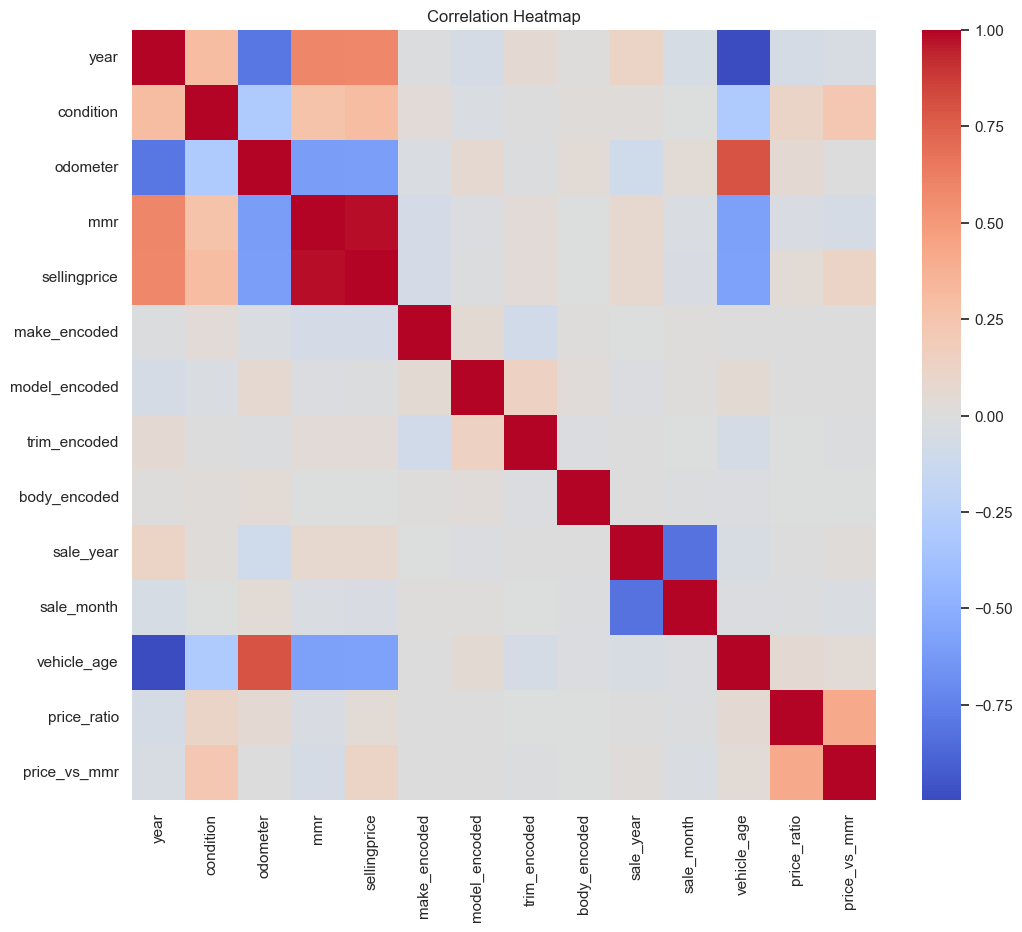

In [78]:
plt.figure(figsize=(12, 10))

sns.heatmap(df_prep.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Some plots with businees qustions to answer

In [ ]:
age_price = (
    df_prep[df_prep['vehicle_age'] <= 20]
    .groupby('vehicle_age')['sellingprice']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)
 
fig5 = go.Figure()
fig5.add_trace(go.Scatter(
    x=age_price['vehicle_age'], y=age_price['mean'],
    mode='lines+markers', name='Mean price',
    line=dict(color='#636EFA', width=2)
))
fig5.add_trace(go.Scatter(
    x=age_price['vehicle_age'], y=age_price['median'],
    mode='lines+markers', name='Median price',
    line=dict(color='#EF553B', width=2, dash='dash')
))
fig5.update_layout(
    title='Average Selling Price by Vehicle Age',
    xaxis_title='Vehicle Age (years)',
    yaxis_title='Selling Price ($)',
    hovermode='x unified'
)
fig5.show()
 

C:\Users\youss\AppData\Local\Temp\ipykernel_29524\3414641928.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




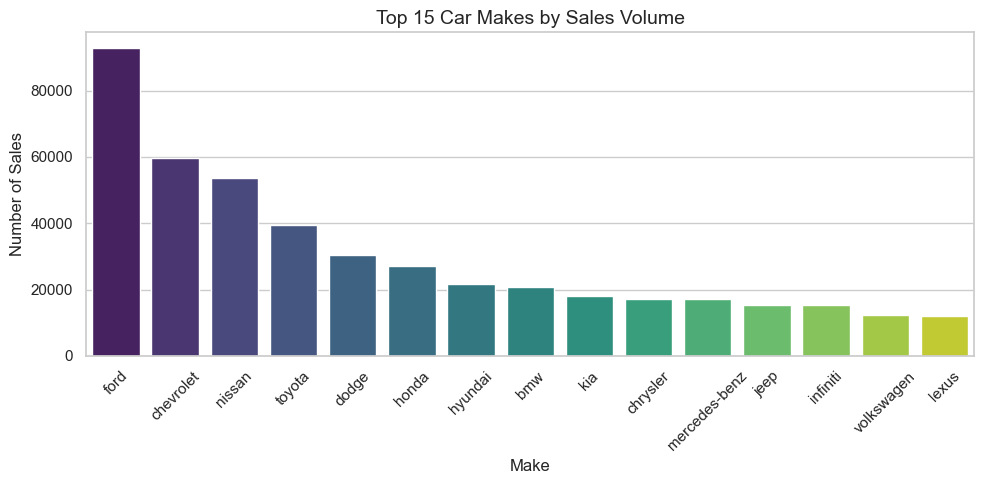

In [90]:
top_makes_vol = df_prep['make'].value_counts().head(15).reset_index()
top_makes_vol.columns = ['make', 'count']
 
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_makes_vol, x='make', y='count', palette='viridis', ax=ax)
ax.set_title('Top 15 Car Makes by Sales Volume', fontsize=14)
ax.set_xlabel('Make')
ax.set_ylabel('Number of Sales')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
make_summary = (
    df_prep.groupby('make')
    .agg(count=('sellingprice', 'count'),
         avg_price=('sellingprice', 'mean'),
         avg_condition=('condition', 'mean'))
    .reset_index()
    .query('count >= 500')          
    .sort_values('count', ascending=False)
    .head(20)
)
 
fig6 = px.scatter(
    make_summary,
    x='avg_price', y='count',
    size='count', color='avg_condition',
    text='make',
    color_continuous_scale='RdYlGn',
    title='Top Makes: Sales Volume vs Avg Price (bubble size = volume)',
    labels={
        'avg_price': 'Avg Selling Price ($)',
        'count': 'Sales Volume',
        'avg_condition': 'Avg Condition'
    }
)
fig6.update_traces(textposition='top center', textfont_size=10)
fig6.show()

In [95]:
df_prep.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,...,model_encoded,trim_encoded,body_encoded,sale_year,sale_month,sale_dayofweek,vehicle_age,price_ratio,price_vs_mmr,condition_bin
0,2015.0,kia,Sorento,LX,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,...,658,998,7,2014.0,12.0,Tuesday,0.0,1.048780,1000.0,1–10
1,2015.0,kia,Sorento,LX,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,...,658,998,7,2014.0,12.0,Tuesday,0.0,1.033654,700.0,1–10
2,2014.0,bmw,3 Series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,...,9,283,6,2015.0,1.0,Wednesday,1.0,0.940439,-1900.0,41–50
3,2015.0,volvo,S60,T5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,...,596,1399,6,2015.0,1.0,Wednesday,0.0,1.009091,250.0,41–50
4,2014.0,bmw,6 Series Gran Coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,...,42,498,6,2014.0,12.0,Thursday,0.0,1.015152,1000.0,41–50


In [96]:
df_prep.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate', 'make_encoded', 'model_encoded',
       'trim_encoded', 'body_encoded', 'sale_year', 'sale_month',
       'sale_dayofweek', 'vehicle_age', 'price_ratio', 'price_vs_mmr',
       'condition_bin'],
      dtype='object')

I removed several columns (vin, state, color, interior, seller, mmr, and saledate) because they either provide no useful predictive information or create a risk of overfitting and data leakage. Columns like vin are identifiers, seller and mmr leak information about the selling price, and color/interior introduce noise due to high cardinality. Removing these features ensures a cleaner dataset and prevents the model from learning unrealistic shortcuts.

In [97]:
cols_to_drop = [
    "vin",          # Unique identifier (no predictive value)
    "state",        # Registration state (weak signal, noisy)
    "color",        # Exterior color
    "interior",     # Interior color
    "seller",       # Seller name (high leakage risk)
    "mmr",          # Estimated market value → causes data leakage
    "saledate",      # Time of sale (leaks time-related info)
    "make_encoded",
    "model_encoded",
    "trim_encoded",
    "body_encoded",
    "condition_bin",
    "price_ratio",
    "price_vs_mmr",
    "sale_year",
    "sale_month",
    "sale_dayofweek"
]

df_model = df_prep.drop(columns=cols_to_drop)

In [98]:
df_model.head()

,year,make,model,trim,body,transmission,condition,odometer,sellingprice,vehicle_age
0,2015.0,kia,Sorento,LX,suv,automatic,5.0,16639.0,21500.0,0.0
1,2015.0,kia,Sorento,LX,suv,automatic,5.0,9393.0,21500.0,0.0
2,2014.0,bmw,3 Series,328i SULEV,sedan,automatic,45.0,1331.0,30000.0,1.0
3,2015.0,volvo,S60,T5,sedan,automatic,41.0,14282.0,27750.0,0.0
4,2014.0,bmw,6 Series Gran Coupe,650i,sedan,automatic,43.0,2641.0,67000.0,0.0


In [99]:
df_model.isna().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
condition       0
odometer        0
sellingprice    0
vehicle_age     0
dtype: int64

In [100]:
df_model.describe()

,year,condition,odometer,sellingprice,vehicle_age
count,541932.000000,541932.000000,541932.000000,541932.00000,541932.000000
mean,2010.222236,31.015742,66400.755968,13841.51767,4.681305
std,3.774805,13.102048,50098.180874,9628.28392,3.750249
min,1984.000000,1.000000,10.000000,500.00000,0.000000
25%,2008.000000,24.000000,28098.750000,7300.00000,2.000000
50%,2012.000000,35.000000,50958.000000,12300.00000,3.000000
75%,2013.000000,42.000000,96656.000000,18400.00000,7.000000
max,2015.000000,49.000000,299999.000000,150000.00000,31.000000


In [101]:
df_model.describe(include='all')

,year,make,model,trim,body,transmission,condition,odometer,sellingprice,vehicle_age
count,541932.000000,541932,541932,541932,541932,541932,541932.000000,541932.000000,541932.00000,541932.000000
unique,NaN,55,953,1935,11,2,NaN,NaN,NaN,NaN
top,NaN,ford,Altima,Base,sedan,automatic,NaN,NaN,NaN,NaN
freq,NaN,92918,19237,54706,246271,525183,NaN,NaN,NaN,NaN
mean,2010.222236,NaN,NaN,NaN,NaN,NaN,31.015742,66400.755968,13841.51767,4.681305
std,3.774805,NaN,NaN,NaN,NaN,NaN,13.102048,50098.180874,9628.28392,3.750249
min,1984.000000,NaN,NaN,NaN,NaN,NaN,1.000000,10.000000,500.00000,0.000000
25%,2008.000000,NaN,NaN,NaN,NaN,NaN,24.000000,28098.750000,7300.00000,2.000000
50%,2012.000000,NaN,NaN,NaN,NaN,NaN,35.000000,50958.000000,12300.00000,3.000000
75%,2013.000000,NaN,NaN,NaN,NaN,NaN,42.000000,96656.000000,18400.00000,7.000000


In [102]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 541932 entries, 0 to 558836
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          541932 non-null  float64
 1   make          541932 non-null  object 
 2   model         541932 non-null  object 
 3   trim          541932 non-null  object 
 4   body          541932 non-null  object 
 5   transmission  541932 non-null  object 
 6   condition     541932 non-null  float64
 7   odometer      541932 non-null  float64
 8   sellingprice  541932 non-null  float64
 9   vehicle_age   541932 non-null  float64
dtypes: float64(5), object(5)
memory usage: 45.5+ MB


Let's save this dataset for future

In [103]:
df_model.to_csv("./dataset/cleaned_dataset.csv", index=False)

### Now It's time to Model this data

In [104]:
df_model.head(10)

,year,make,model,trim,body,transmission,condition,odometer,sellingprice,vehicle_age
0,2015.0,kia,Sorento,LX,suv,automatic,5.0,16639.0,21500.0,0.0
1,2015.0,kia,Sorento,LX,suv,automatic,5.0,9393.0,21500.0,0.0
2,2014.0,bmw,3 Series,328i SULEV,sedan,automatic,45.0,1331.0,30000.0,1.0
3,2015.0,volvo,S60,T5,sedan,automatic,41.0,14282.0,27750.0,0.0
4,2014.0,bmw,6 Series Gran Coupe,650i,sedan,automatic,43.0,2641.0,67000.0,0.0
5,2015.0,nissan,Altima,2.5 S,sedan,automatic,1.0,5554.0,10900.0,0.0
6,2014.0,bmw,M5,Base,sedan,automatic,34.0,14943.0,65000.0,0.0
7,2014.0,chevrolet,Cruze,1LT,sedan,automatic,2.0,28617.0,9800.0,0.0
8,2014.0,audi,A4,2.0T Premium Plus quattro,sedan,automatic,42.0,9557.0,32250.0,0.0
9,2014.0,chevrolet,Camaro,LT,convertible,automatic,3.0,4809.0,17500.0,1.0


I will use XGBoost as a regressor:
I will not use one-hot encoding because XGBosst natively supports integer-encoded categorical features (Label Encoding)

In [105]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ["make", "model", "trim", "body", "transmission"]

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

After Encoding

In [106]:
df_model.head()

,year,make,model,trim,body,transmission,condition,odometer,sellingprice,vehicle_age
0,2015.0,26,647,987,7,0,5.0,16639.0,21500.0,0.0
1,2015.0,26,647,987,7,0,5.0,9393.0,21500.0,0.0
2,2014.0,5,9,282,6,0,45.0,1331.0,30000.0,1.0
3,2015.0,54,586,1385,6,0,41.0,14282.0,27750.0,0.0
4,2014.0,5,40,496,6,0,43.0,2641.0,67000.0,0.0


Split the data into train and test

In [107]:
from sklearn.model_selection import train_test_split

X = df_model.drop("sellingprice", axis=1)
y = df_model["sellingprice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [108]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"   
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Evaluation of the model

In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))


MAE: 1288.7459906930237
RMSE: 2110.567150565571
R2: 0.9524223634069


I will try to het a higher accuracy:


I used RandomizedSearchCV with 5‑fold cross‑validation to tune the XGBoost regression model. K‑Fold CV prevents overfitting by evaluating each parameter combination on multiple splits of the data. RandomizedSearchCV efficiently explores the search space and finds high‑performing hyperparameters faster than GridSearch. After tuning, the best model is retrained using the optimized hyperparameters and evaluated using MAE, RMSE, and R². 

In [110]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)



In [ ]:
param_grid = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3],
}

xgb = XGBRegressor(
    tree_method="hist",
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,                   
    cv=kf,                       
    scoring="neg_mean_absolute_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [115]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [116]:
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [117]:
# Predict using best model
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", f"{mae:.2f}")
print("RMSE:", f"{rmse:.2f}")
print("R2:", f"{r2:.2f}")

MAE: 1203.25
RMSE: 2013.02
R2: 0.96
